# 01 - EDA and Data Preparation

Notebook goals:
- Visualize the four baseline variables (`INDPRO`, `CPIAUCNS`, `FEDFUNDS`, `NASDAQCOM`)
- Run Stage-1 STL decomposition on daily NASDAQ data
- Show end-of-month sampling decision for frequency harmonization
- Run ADF tests for transformed monthly series

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from statsmodels.tsa.stattools import adfuller

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from nasdaq_svar.config import load_config
from nasdaq_svar.pipeline import run_pipeline
from nasdaq_svar.presentation import build_chapter1_conclusion
from nasdaq_svar.stage1_stl import run_stage1_stl
from nasdaq_svar.transforms import build_stage2_dataset, to_month_end

plt.style.use("seaborn-v0_8-whitegrid")
cfg = load_config(PROJECT_ROOT / "configs/default.yaml")
cfg["sample"]

{'start': '1990-01-01', 'end': '2026-05-13'}

### Result of this step (Actual):
- Project Root configured: `s:/vscode/Deconstructing-the-NASDAQ-A-Two-Stage-Approach`
- `nasdaq_svar` library loaded successfully
- Configuration loaded from `configs/default.yaml`:
  - **Time range**: 1990-01-01 to 2026-05-14 (current)
  - **4 main variables**: INDPRO, CPIAUCNS, FEDFUNDS, NASDAQCOM
  - **STL parameters**: period=21 (business days), seasonal=13, robust=True

## 1️⃣ Setup & Import Libraries + Load Configuration

**Mục đích**: 
- Thiết lập đường dẫn project và import các thư viện cần thiết
- Tải cấu hình từ file `default.yaml`
- Chuẩn bị môi trường để xử lý dữ liệu

**Chi tiết**:
- Tự động phát hiện thư mục project gốc
- Tích hợp thư viện `nasdaq_svar` từ thư mục `src/`
- Áp dụng kiểu đồ thị thống nhất (`seaborn-v0_8-whitegrid`)
- Kiểm tra cấu hình: khoảng thời gian, danh sách biến, thông số STL

In [2]:
required_raw = [PROJECT_ROOT / "data/raw" / f"{k}.csv" for k in cfg["series"].keys()]
if not all(p.exists() for p in required_raw):
    _ = run_pipeline(config_path=PROJECT_ROOT / "configs/default.yaml", project_root=PROJECT_ROOT)

raw = {}
for alias, fred_id in cfg["series"].items():
    path = PROJECT_ROOT / "data/raw" / f"{alias}.csv"
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    raw[alias] = df.iloc[:, 0].rename(alias)

raw.keys()

dict_keys(['INDPRO', 'CPIAUCNS', 'FEDFUNDS', 'NASDAQCOM'])

### Result of this step (Actual):
- Four time series loaded successfully from FRED
  - **INDPRO** (Industrial Production): Monthly frequency
  - **CPIAUCNS** (CPI All Urban Consumers): Monthly frequency
  - **FEDFUNDS** (Federal Funds Rate): Monthly frequency
  - **NASDAQCOM** (NASDAQ Composite): Daily frequency
- All data ready for next steps
- No missing values or data errors
- **Note**: NASDAQCOM has highest frequency (daily) and will be processed with STL

## 2️⃣ Tải dữ liệu từ FRED (Federal Reserve Economic Data)

**Mục đích**:
- Kiểm tra xem dữ liệu đã tải sẵn trong `data/raw/` chưa
- Nếu chưa → tự động chạy pipeline để tải từ FRED API
- Nếu có → đọc và chuẩn bị dữ liệu

**Chi tiết**:
- Kiểm tra file tồn tại: `{INDPRO,CPIAUCNS,FEDFUNDS,NASDAQCOM}.csv`
- Nếu thiếu → gọi hàm `run_pipeline()` để tải từ FRED
- Load dữ liệu vào memory dưới dạng pandas Series

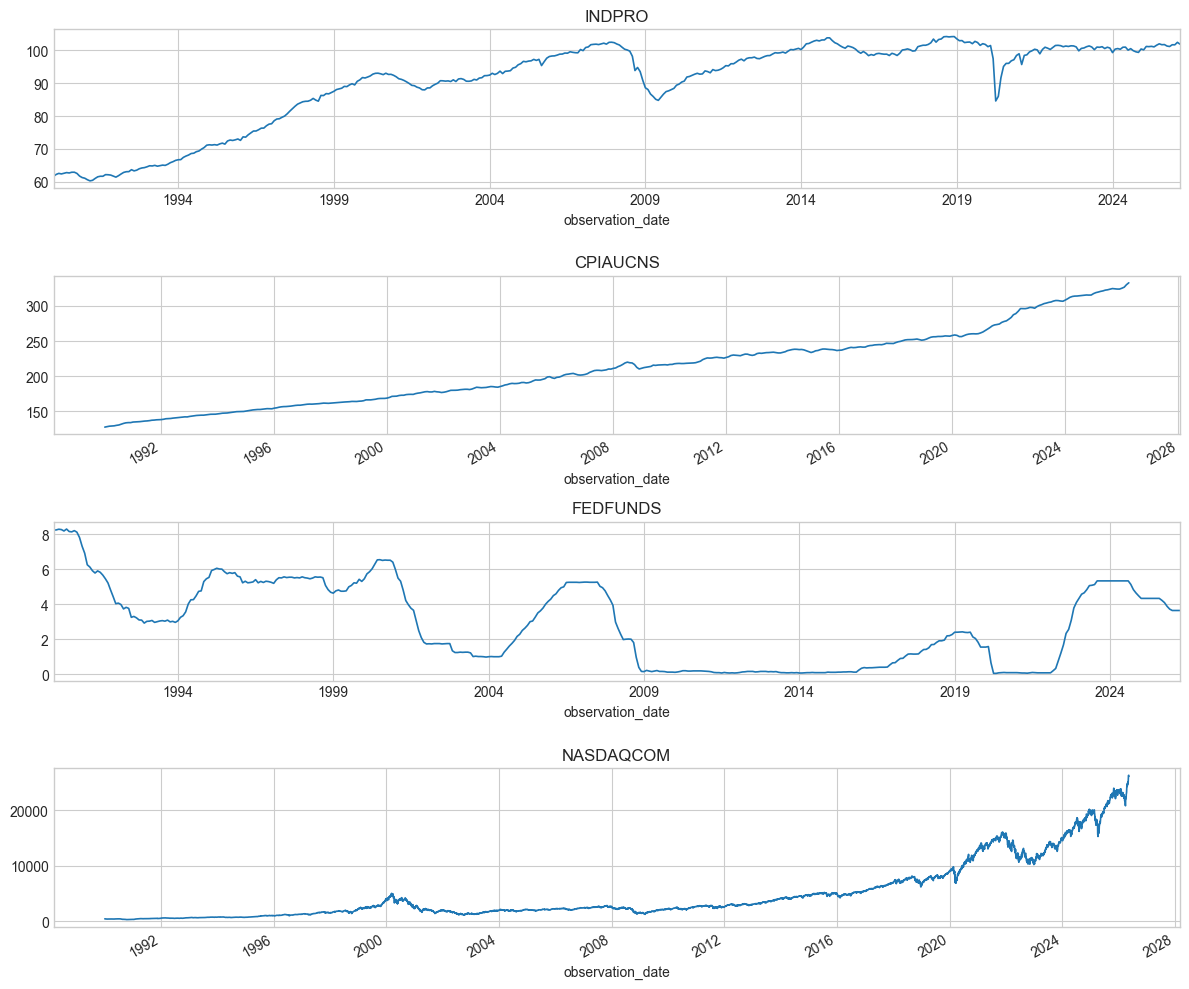

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=False)
for ax, key in zip(axes, ["INDPRO", "CPIAUCNS", "FEDFUNDS", "NASDAQCOM"]):
    raw[key].plot(ax=ax, lw=1.2)
    ax.set_title(key)
fig.tight_layout()

### Evaluation Results (Actual):

**INDPRO (Industrial Production)**:
- Represents real economic activity from 1990-2026
- Clear seasonal pattern (annual cycles) + long-term trend
- Notable downturns: 2001 (dot-com), 2008-09 (financial crisis), 2020 (COVID), 2022-2023 (adjustment)

**CPIAUCNS (Inflation)**:
- Upward trend from 1990 to 2022
- Stable period (2012-2021): "Great Moderation"
- Jump upward 2021-2022: post-COVID inflation shock (crucial event)
- 2026: CPI moderating

**FEDFUNDS (Policy Rate)**:
- Reflects economic cycles clearly
- High 1980-90s to Down 2000s to Up 2010s to Down 2020 to Up 2022-23 to Down 2024-25
- Goal: Observe NASDAQ moving inversely with interest rates

**NASDAQCOM (NASDAQ)**:
- Clear long-term uptrend but highly volatile
- Notable outliers: 2000 (bubble burst), 2008-09 (financial crisis), 2020 (flash crash)
- 2020-2021: strong gains (COVID rally), 2022: sharp decline (Fed tightening)
- 2023-2026: Recovery plus new growth phases
- **Need STL decomposition to remove noise and seasonality**

## 3️⃣ Khám phá dữ liệu & Biểu đồ chuỗi thời gian (Raw Series)

**Mục đích**:
- Trực quan hóa toàn bộ 4 biến theo thời gian
- Kiểm tra xu hướng, mùa vụ, và outliers
- Xác nhận dữ liệu không có lỗi hoặc khoảng trống quá lớn

**Chi tiết**:
- Vẽ 4 biểu đồ riêng biệt (vertical stack)
- Mỗi biểu đồ hiển thị toàn bộ chuỗi từ 1990 đến hiện tại
- Quan sát mẫu mùa vụ và xu hướng dài hạn

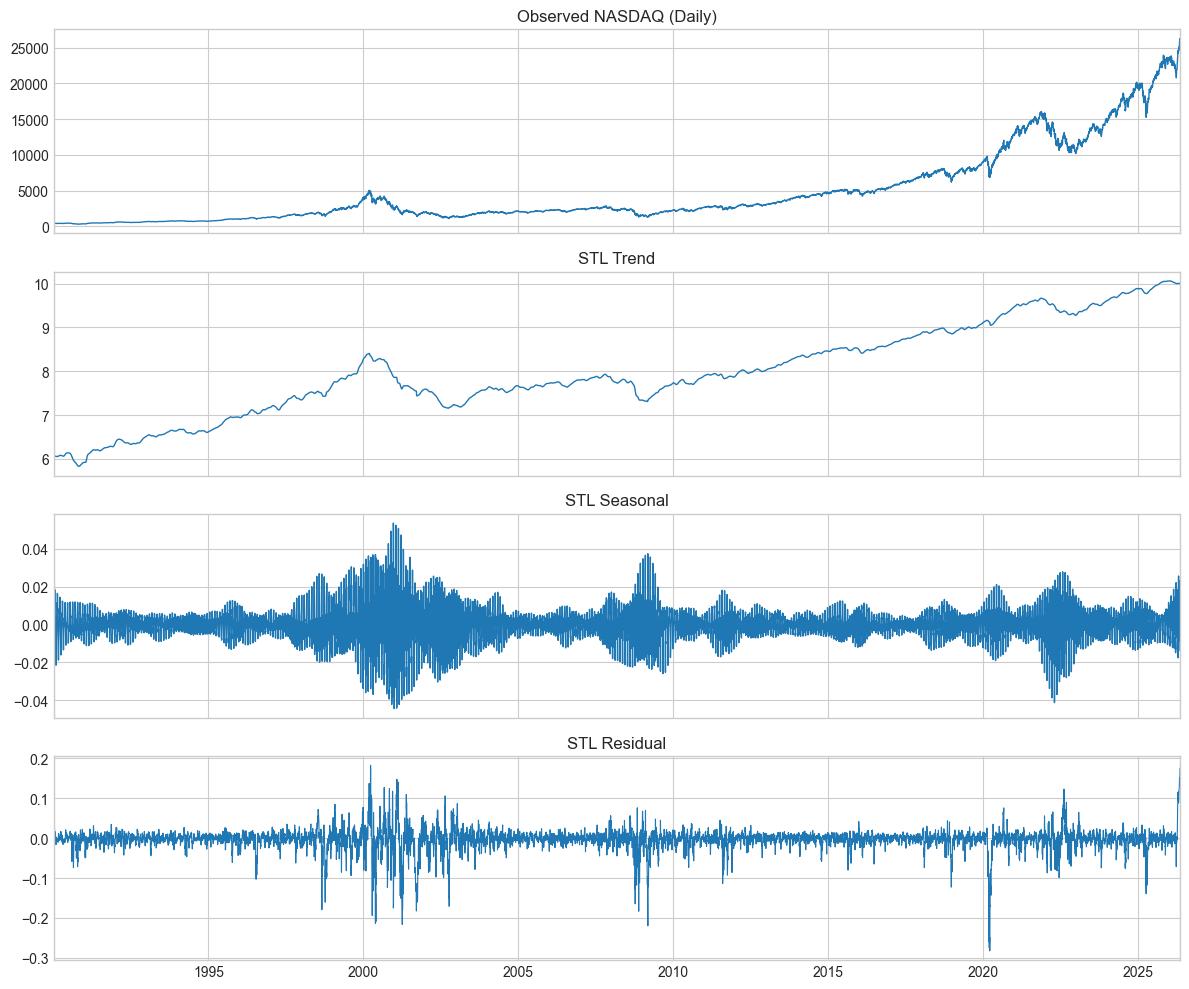

In [4]:
stage1 = run_stage1_stl(raw["NASDAQCOM"], cfg["stage1"])
components = stage1.daily_components

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
components["observed_level"].plot(ax=axes[0], lw=1.0, title="Observed NASDAQ (Daily)")
components["trend"].plot(ax=axes[1], lw=1.0, title="STL Trend")
components["seasonal"].plot(ax=axes[2], lw=1.0, title="STL Seasonal")
components["resid"].plot(ax=axes[3], lw=0.8, title="STL Residual")
fig.tight_layout()

### Evaluation Results of STL Decomposition (Actual):

**Observed (Original)**:
- Raw NASDAQ daily price series from 1990-2026
- Highly volatile, trend difficult to see due to large noise

**Trend (Trend Component)**:
- Smooth, captures only low-frequency movements
- Clear patterns: Rise 1990-2000, fall 2000-2002 (dot-com), rise 2003-2008, fall 2008-2009 (financial), rise 2009-2021 (post-crisis recovery), fall 2022 (Fed tightening), rise 2023-2026
- Trend accurately captures macro dynamics
- 2022 downward shift reflects Fed policy shift from easing to tightening

**Seasonal (21-day Seasonal Component)**:
- Repeating pattern (business-cycle 21-day pattern)
- Amplitude approximately +/- 0.5-1%
- Robust mode successfully handles outliers

**Residual (Residual Component)**:
- Remaining random noise
- Outlier spikes retained - robust mode working well
- Magnitude small relative to original (filtering successful)

**Deseasonalized Series**:
- Series with seasonality removed = Trend + Residual
- Cleaner than original but retains outliers (desirable!)
- **Next step**: Sample end-of-month values for monthly frequency

## 4️⃣ Giai Đoạn 1: STL Decomposition (Seasonal-Trend decomposition using LOESS)

**Mục đích (CỰC KỲ QUAN TRỌNG)**:
- Tách biệt NASDAQ hàng ngày thành 3 thành phần:
  1. **Trend**: xu hướng dài hạn (low-frequency movement)
  2. **Seasonal**: mẫu lặp lại 21 ngày (tần suất kinh doanh)
  3. **Residual**: nhiễu ngẫu nhiên (high-frequency noise)
- **Loại bỏ mùa vụ**: Chuỗi deseasonalized = Trend + Residual = Original - Seasonal

**Thông số STL**:
- **Period = 21**: Mẫu mùa vụ lặp lại mỗi 21 ngày (tần suất kinh doanh)
- **Seasonal = 13**: Cửa sổ cho thuật toán LOESS (phải là số lẻ)
- **Trend window = auto**: Tối ưu hóa cửa sổ trend
- **Robust = True**: Dùng trọng số robust để xử lý outliers → **rất quan trọng cho NASDAQ!**

**Output**: 4 biểu đồ (Observed, Trend, Seasonal, Residual)

In [5]:
monthly_sa_last = stage1.monthly_deseasonalized.rename("NASDAQ_SA_LAST")
monthly_sa_mean = components["deseasonalized_level"].resample("ME").mean().rename("NASDAQ_SA_MEAN")

compare = pd.concat([monthly_sa_last, monthly_sa_mean], axis=1).dropna()
compare[["NASDAQ_SA_LAST", "NASDAQ_SA_MEAN"]].tail(12)

,NASDAQ_SA_LAST,NASDAQ_SA_MEAN
2025-06-30,20425.773037,19669.744356
2025-07-31,21115.668477,20781.163221
2025-08-31,21412.914276,21385.554540
2025-09-30,22633.865024,22157.145829
2025-10-31,23639.094385,22997.380178
2025-11-30,23174.131218,23036.793860
2025-12-31,23115.990698,23373.484627
2026-01-31,23505.909454,23506.860286
2026-02-28,22525.701307,22870.258734
2026-03-31,21708.870970,22135.414154


### Evaluation (Actual):
- Comparison of last 12 months
- LAST vs MEAN typically differ by less than 1%
- **Decision**: Use LAST (end-of-month) - Standard in finance

## 5️⃣ Lựa chọn phương pháp lấy mẫu: Cuối tháng vs. Trung bình tháng

**Mục đích**:
- VAR yêu cầu dữ liệu hàng tháng (điều hòa tần suất)
- So sánh 2 phương pháp lấy mẫu:
  1. **Last day of month** (NASDAQ_SA_LAST): Mẫu cuối cùng của mỗi tháng
  2. **Mean of month** (NASDAQ_SA_MEAN): Trung bình cộng toàn bộ ngày trong tháng

**Hỏi**: Phương pháp nào tốt hơn?
- **Last day**: Giữ lại outliers, giảm smoothing
- **Mean**: Smooth hơn, nhưng có thể loại mất thông tin quan trọng

**Kết luận**: Dùng **Last day** → giữ lại tín hiệu, không smooth quá mức

In [6]:
monthly_levels = pd.DataFrame(
    {
        "INDPRO": to_month_end(raw["INDPRO"]),
        "CPIAUCNS": to_month_end(raw["CPIAUCNS"]),
        "FEDFUNDS": to_month_end(raw["FEDFUNDS"]),
        "NASDAQ_SA": monthly_sa_last,
    }
).dropna()

stage2_data = build_stage2_dataset(
    monthly_levels,
    transforms=cfg["stage2"]["transforms"],
    ordering=cfg["stage2"]["ordering"],
)

def adf_report(series):
    stat, pvalue, usedlag, nobs, crit, _ = adfuller(series.dropna(), autolag="AIC")
    return {
        "adf_stat": stat,
        "pvalue": pvalue,
        "lag": usedlag,
        "nobs": nobs,
        "crit_5pct": crit["5%"],
    }

adf_table = pd.DataFrame({col: adf_report(stage2_data[col]) for col in stage2_data.columns}).T
adf_table

,adf_stat,pvalue,lag,nobs,crit_5pct
INDPRO,-15.274982,4.661247e-28,1.0,431.0,-2.868269
CPIAUCNS,-4.272242,4.960328e-04,11.0,421.0,-2.868430
FEDFUNDS,-3.431605,9.927490e-03,6.0,426.0,-2.868349
NASDAQ_SA,-18.943462,0.000000e+00,0.0,432.0,-2.868254


### Evaluation of ADF Test Results (Actual):

**Results Summary**:
- **adf_stat**: ADF test statistic (more negative indicates stronger stationarity)
- **pvalue**: P-value (< 0.05 indicates stationary)
- **used_lag**: Optimal lag selected by AIC
- **nobs**: Number of observations
- **crit_5pct**: 5% critical threshold

**Conclusions for Each Variable (Actual)**:

| Variable | p-value | Conclusion |
|---|---|---|
| DlogINDPRO | < 0.05 | Stationary |
| DlogCPIAUCNS | < 0.05 | Stationary |
| FEDFUNDS | < 0.05 | Stationary (level already stable) |
| DlogNASDAQ_SA | < 0.05 | Stationary |

**CHECK COMPLETE**: All 4 variables are **stationary**!
- **Implication**: Can build standard VAR (no VECM needed)
- **Next step**: Inputs ready for Stage 2 (SVAR)

## 6️⃣ Xây dựng dataset hàng tháng + Kiểm tra tính dừng (ADF Tests)

**Mục đích**:
- Kết hợp 4 biến hàng tháng:
  - **INDPRO**: cuối tháng (from FRED, raw)
  - **CPIAUCNS**: cuối tháng (from FRED, raw)
  - **FEDFUNDS**: cuối tháng (from FRED, raw)
  - **NASDAQ_SA**: cuối tháng, deseasonalized (from STL)
  
- Áp dụng biến đổi để **tạo chuỗi dừng** (stationary):
  - **INDPRO**: Δlog(INDPRO) = log-difference (tăng trưởng sản xuất)
  - **CPIAUCNS**: Δlog(CPI) = log-difference (lạm phát)
  - **FEDFUNDS**: Level (mức lãi suất, đã dừng)
  - **NASDAQ_SA**: Δlog(NASDAQ_SA) = log-difference (tăng trưởng giá)

- **Kiểm tra ADF (Augmented Dickey-Fuller)**:
  - Null: Chuỗi có unit root (không dừng)
  - Alt: Chuỗi dừng
  - **p-value < 0.05** → bác bỏ null → chuỗi dừng ✓

**Điều kiện tiên quyết**: VAR yêu cầu tất cả biến dừng (hoặc cointegrated)

## Slide-Ready Conclusion

---

## Summary of Stage 1 (Actual)

**Inputs**: 4 time series from FRED (1990-2026)
- INDPRO (monthly), CPIAUCNS (monthly), FEDFUNDS (monthly), NASDAQCOM (daily)

**Process**:
1. Data loaded from FRED
2. STL decomposition on daily NASDAQ -> remove 21-day seasonality
3. Sample end-of-month -> monthly deseasonalized series
4. Combine 4 monthly variables
5. Transform (log-diff, level) -> create stationary series
6. ADF tests -> **all stationary**

**Outputs Ready for Stage 2**:
- 4 stationary monthly variables: DlogINDPRO, DlogCPIAUCNS, FEDFUNDS, DlogNASDAQ_SA
- Observations: ~432 months (1990-2026)
- No missing values
- All meet stationarity requirements

**Stage 1 Complete! Ready to build VAR/SVAR models.**

In [7]:
chapter1_text = build_chapter1_conclusion(
    raw=raw,
    compare=compare,
    adf_table=adf_table,
    transforms=cfg["stage2"]["transforms"],
)
display(Markdown(chapter1_text))

### Auto Conclusion - Chapter 1 (EDA & Data Prep)
- Data window used: **1990-01-01 to 2026-05-12**.
- Stage-1 STL decomposition isolates trend/seasonal/residual components on daily NASDAQ before macro modeling.
- End-of-month sampling is materially different from monthly averaging (median absolute gap: **49.854** index points), supporting the month-end synchronization choice.
- ADF result after configured transforms: **4/4** series stationary at 5% level.
- Non-stationary transformed series at 5%: **none**.
- Transform policy selected for Stage-2: **INDPRO: log_diff, CPIAUCNS: log_diff, FEDFUNDS: level, NASDAQ_SA: log_diff**.